# Big Data Project: Wetter- und Luftqualitätsdaten

## Einleitung

Dieses Projekt sammelt Wetter- und Luftqualitätsdaten, speichert die Rohdaten lokal als JSON und legt sie zusätzlich in MongoDB ab.

**Ziel des ersten Setups:**
- Python-Abhängigkeiten installieren
- Projektordner vorbereiten
- `.env` und MongoDB-Verbindung prüfen
- das Projekt mit `src.main` starten

**Aktueller Ablauf im Projekt:**
1. Wetterdaten laden
2. Luftqualitätsdaten laden
3. Rohdaten in `data/raw/...` speichern
4. Daten in MongoDB-Collections ablegen


## Setup

Vor dem Start bitte sicherstellen:
- Python 3 und ein aktives Projekt-Environment
- Docker bzw. Docker Desktop laeuft
- `docker compose` ist verfuegbar
- die folgende Setup-Zelle wird vor `src.main` ausgefuehrt

Die Setup-Zelle:
1. wechselt ins Projektverzeichnis
2. legt `.env` aus `.env.example` an, falls noetig
3. lädt die benoetigten Umgebungsvariablen
4. prüft Docker
5. startet den MongoDB-Container aus `docker-compose.yml`

Verwendete Standardwerte für `.env`:

```env
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
WEATHER_API_KEY=
WEATHER_USE_MOCK=true
WEATHER_LAT=48.2082
WEATHER_LON=16.3738
WEATHER_UNITS=metric
WEATHER_LANG=de
WEATHER_EXCLUDE=minutely,alerts
AIR_QUALITY_API_KEY=
OPENAQ_LOCATION_ID=8118
```


### Abhängigkeiten prüfen

Die folgende Zelle prüft die benötigten Python-Pakete für das Notebook und aktiviert sie bei Bedarf. Die Hilfsmethode liegt in `src/notebook_methods.py` als `ensure_notebook_dependencies()`.


In [13]:
from src.notebook_methods import ensure_notebook_dependencies

ensure_notebook_dependencies()


HTTP-Anfragen: verfügbar und aktiv
MongoDB-Anbindung: verfügbar und aktiv
Umgebungsvariablen: verfügbar und aktiv
Matplotlib: verfügbar und aktiv
Pandas: verfügbar und aktiv


**Hinweis:** Wenn `docker` oder `docker compose` nicht gefunden wird, bitte sicherstellen, dass Docker Desktop installiert und gestartet ist. Unter Linux muss eventuell der Docker-Daemon mit `sudo systemctl start docker` gestartet werden.

### Docker-Erreichbarkeit prüfen

Die folgende Zelle testet, ob Docker grundsätzlich erreichbar ist, bevor Container gestartet werden. Die Prüfung läuft direkt in dieser Notebook-Zelle.


In [14]:
import subprocess

subprocess.run(
    ["docker", "ps"],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
print("Docker ist erreichbar.")

Docker ist erreichbar.


### Notebook-Umgebung vorbereiten

Die folgende Zelle setzt das Arbeitsverzeichnis, lädt die `.env`-Werte und startet den MongoDB-Container. Die Hilfsmethode liegt in `src/notebook_methods.py` als `prepare_notebook_environment()`.


In [15]:
from src.notebook_methods import prepare_notebook_environment

project_dir = prepare_notebook_environment()


Arbeitsverzeichnis: C:\Users\aylin\DataspellProjects\BigData1
.env bereits vorhanden
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
MongoDB-Container laeuft.


### Datenordner anlegen

Die folgende Zelle stellt sicher, dass die Ordner `data/raw/weather`, `data/raw/air_quality` und `data/processed` vorhanden sind. Die Logik liegt direkt in dieser Notebook-Zelle.


In [16]:
from pathlib import Path

folders = [
    Path("data/raw/weather"),
    Path("data/raw/air_quality"),
    Path("data/processed"),
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Ordner bereit: {folder}")


Ordner bereit: data\raw\weather
Ordner bereit: data\raw\air_quality
Ordner bereit: data\processed


### Environment-Konfiguration anzeigen

Die folgende Zelle zeigt die wichtigsten `.env`-Einstellungen an und maskiert den Zustand der API-Keys. Die Hilfsmethode liegt in `src/notebook_methods.py` als `show_notebook_env_settings()`.


In [17]:
from src.notebook_methods import show_notebook_env_settings

show_notebook_env_settings()


.env gefunden
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
WEATHER_API_KEY=gesetzt
AIR_QUALITY_API_KEY=gesetzt


## Projektstart

Die nächste Zelle startet den aktuellen Einstiegspunkt `src.main` mit demselben Python-Interpreter wie das Notebook. Dabei werden Beispiel-Datensätze erzeugt, lokal gespeichert und in MongoDB geschrieben.


### Datenerhebung ausführen

Die folgende Zelle startet den Projekteinstiegspunkt `src.main`, ruft Wetter- und Luftqualitätsdaten ab und speichert die Rohdaten lokal sowie in MongoDB.


In [18]:
import subprocess
import sys

_ = subprocess.run([sys.executable, "-m", "src.main"], cwd=project_dir, check=True)


## MapReduce

Die naechsten Zellen zeigen zuerst die flach vorbereiteten Rohdaten, fuehren danach explizit die **MapReduce**-Pipeline aus und stellen anschliessend die verarbeiteten Daten als Tabelle dar.


### MapReduce-Rohdaten darstellen

Die folgende Zelle zeigt die für MapReduce flach vorbereiteten Rohdaten als Tabelle. Die Hilfsmethode liegt in `src/notebook_methods.py` als `render_MapReduce_raw_table()`.


In [19]:
from src.notebook_methods import render_MapReduce_raw_table

render_MapReduce_raw_table()


Stadt,Datum,Zeitpunkt,Temperatur (°C),Wetter,Luftqualitaet,Einheit,Fehlendes Wetter,Fehlende Luftqualitaet
Vienna,2025-01-01,2025-01-01T12:00:00+01:00,-0.24,Mäßig bewölkt,29.5,µg/m³,nein,nein
Vienna,2025-01-27,2025-01-27T12:00:00+01:00,8.30,Bedeckt,11.5,µg/m³,nein,nein
Vienna,2025-02-22,2025-02-22T12:00:00+01:00,5.75,Klarer Himmel,31.2,µg/m³,nein,nein
Vienna,2025-03-20,2025-03-20T12:00:00+01:00,10.76,Klarer Himmel,-1.0,µg/m³,nein,nein
Vienna,2025-04-15,2025-04-15T12:00:00+02:00,15.38,Leichter Regen,10.7,µg/m³,nein,nein
Vienna,2025-05-11,2025-05-11T12:00:00+02:00,15.91,Überwiegend bewölkt,5.33,µg/m³,nein,nein
Vienna,2025-06-06,2025-06-06T12:00:00+02:00,26.44,Ein paar Wolken,4.11,µg/m³,nein,nein
Vienna,2025-07-02,2025-07-02T12:00:00+02:00,29.57,Klarer Himmel,-1.0,µg/m³,nein,nein
Vienna,2025-07-28,2025-07-28T12:00:00+02:00,20.79,Bedeckt,5.45,µg/m³,nein,nein
Vienna,2025-08-23,2025-08-23T12:00:00+02:00,19.44,Bedeckt,3.34,µg/m³,nein,nein


### MapReduce ausfuehren

Die folgende **MapReduce**-Codezeile startet die Verarbeitung, ergänzt fehlende numerische Werte mit **Durchschnitt aus vorherigem und naechstem Zeitpunkt** und schreibt das Ergebnis nach `data/processed/`.


### MapReduce-Pipeline starten

Die folgende Zelle führt die explizite MapReduce-Verarbeitung aus. Die Pipeline liegt in `src/MapReduce.py` und ergänzt fehlende numerische Werte per Nachbar-Mittelwert.


In [20]:
from src.MapReduce import run_MapReduce_pipeline; mapreduce_result = run_MapReduce_pipeline()


MapReduce verarbeitet: 45 Rohdatensaetze.
MapReduce gespeichert: data\processed\MapReduce_20260423_103519.json


### MapReduce Processed Data

Hier steht die verarbeitete **MapReduce**-Ausgabe mit den ergaenzten Werten. `ja` markiert die Stellen, an denen ein fehlender Wert per Nachbar-Mittelwert imputiert wurde.


### Verarbeitete MapReduce-Daten anzeigen

Die folgende Zelle zeigt die verarbeiteten Daten inklusive Imputationsmarkierung an. Die Hilfsmethode liegt in `src/notebook_methods.py` als `render_MapReduce_processed_table()`.


In [21]:
from src.notebook_methods import render_MapReduce_processed_table

render_MapReduce_processed_table(mapreduce_result)


Stadt,Datum,Zeitpunkt,Temperatur (°C),Wetter,Luftqualitaet,Einheit,Temperatur imputiert,Luftqualitaet imputiert
Vienna,2025-01-01,2025-01-01T12:00:00+01:00,-0.24,Mäßig bewölkt,29.50,µg/m³,nein,nein
Vienna,2025-01-27,2025-01-27T12:00:00+01:00,8.30,Bedeckt,11.50,µg/m³,nein,nein
Vienna,2025-02-22,2025-02-22T12:00:00+01:00,5.75,Klarer Himmel,31.20,µg/m³,nein,nein
Vienna,2025-03-20,2025-03-20T12:00:00+01:00,10.76,Klarer Himmel,-1.00,µg/m³,nein,nein
Vienna,2025-04-15,2025-04-15T12:00:00+02:00,15.38,Leichter Regen,10.70,µg/m³,nein,nein
Vienna,2025-05-11,2025-05-11T12:00:00+02:00,15.91,Überwiegend bewölkt,5.33,µg/m³,nein,nein
Vienna,2025-06-06,2025-06-06T12:00:00+02:00,26.44,Ein paar Wolken,4.11,µg/m³,nein,nein
Vienna,2025-07-02,2025-07-02T12:00:00+02:00,29.57,Klarer Himmel,-1.00,µg/m³,nein,nein
Vienna,2025-07-28,2025-07-28T12:00:00+02:00,20.79,Bedeckt,5.45,µg/m³,nein,nein
Vienna,2025-08-23,2025-08-23T12:00:00+02:00,19.44,Bedeckt,3.34,µg/m³,nein,nein


## Datenvisualisierung
In den nächsten Zellen werden die in MongoDB gespeicherten Daten geladen und mit `pandas` und `matplotlib` visualisiert. Es werden einfache Zeitreihenplots der Wetter- und Luftqualitaetsdaten erstellt.

Zunächst importieren wir pandas zur Datenverarbeitung und matplotlib für die Visualisierung. Außerdem importieren wir die Funktion `get_database` aus unserem MongoDB-Client-Modul, um eine Verbindung zur Datenbank herzustellen und die Daten zu laden. Danach werden die Daten aus der Datenbank geladen und in einem DataFrame gespeichert, um sie für die Visualisierung vorzubereiten.

Die folgende Zelle visualisiert die Durchschnittswerte aus den MapReduce-Ergebnissen als Balkendiagramme, um einen Vergleich zwischen den Städten zu ermöglichen.

Zunächst werden matplot, pandas und numpy importiert, um die Daten verarbeiten und visualisieren zu können. Anschließend wird die neueste verarbeitete MapReduce-Ausgabe geladen, um die Zusammenfassung der Daten zu erhalten, die für die Visualisierung verwendet werden soll.

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.MapReduce import load_latest_processed_result
mapreduce_result = load_latest_processed_result()
summary_records = mapreduce_result["summary_records"]
print(f"MapReduce-Datei: {mapreduce_result['processed_file']}")
print(f"Zusammengefasste Datensätze: {len(summary_records)} Städte")

MapReduce-Datei: data\processed\MapReduce_20260423_103519.json
Zusammengefasste Datensätze: 3 Städte


Anschließend werden Balkendiagramme erstellt, die die Durchschnittstemperatur und die durchschnittliche Luftqualität für die drei Städte (Wien, New York und Neu Delhi) zeigen. Die Temparatur ist dabei in °C angegeben, während bei der Luftqualität angegeben wird, wie viele Mikrogramm PM2.5 (Feinstaub) pro Kubikmeter Luft vorhanden sind. Laut WHO wird die Anzahl an Feinstaub wie folgt bewertet: < 15 µg/m³ = Gut
15-35 µg/m³ = Moderat/Akzeptabel
35-75 µg/m³ = Ungesund für empfindliche Gruppen
> 75 µg/m³ = Ungesund für alle

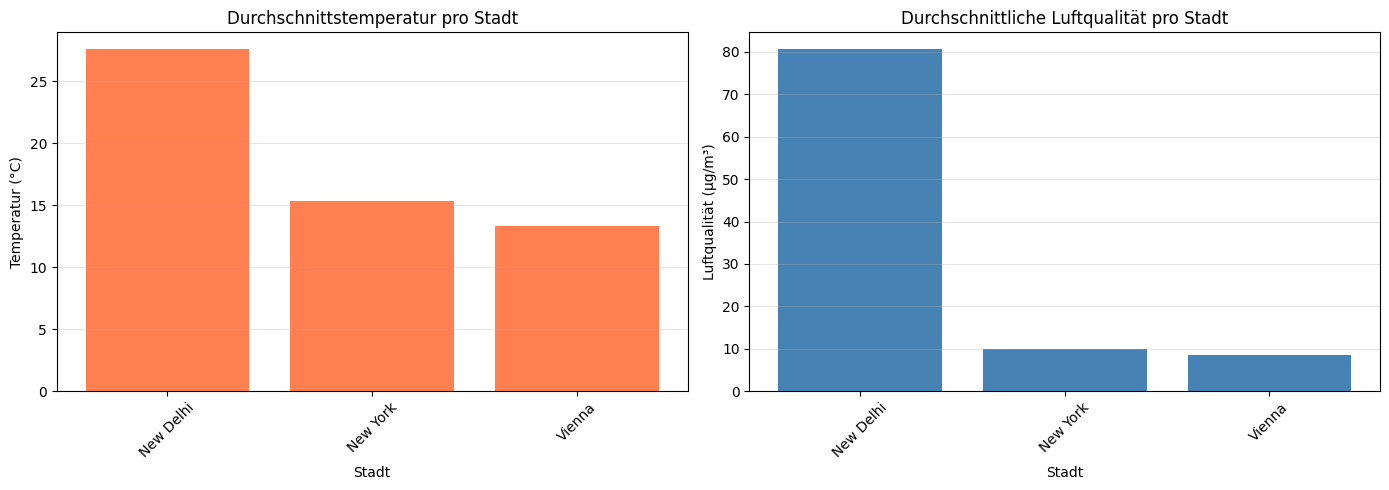

In [25]:
if summary_records:
    summary_df = pd.DataFrame(summary_records)
    summary_df = summary_df.dropna(subset=["average_temperature_c", "average_air_quality"])

    if not summary_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Temperatur-Balkendiagramm
        axes[0].bar(summary_df["city"], summary_df["average_temperature_c"], color="coral")
        axes[0].set_title("Durchschnittstemperatur pro Stadt")
        axes[0].set_ylabel("Temperatur (°C)")
        axes[0].set_xlabel("Stadt")
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(True, alpha=0.3, axis='y')

        # Luftqualität-Balkendiagramm
        unit = summary_df.iloc[0]['air_quality_unit']
        axes[1].bar(summary_df["city"], summary_df["average_air_quality"], color="steelblue")
        axes[1].set_title(f"Durchschnittliche Luftqualität pro Stadt")
        axes[1].set_ylabel(f"Luftqualität ({unit})")
        axes[1].set_xlabel("Stadt")
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()
    else:
        print("Keine gültigen Daten für Visualisierung.")
else:
    print("MapReduce-Ergebnisse nicht verfügbar.")


Um herauszufinden, ob es einen Zusammenhang zwischen Luftqualität und Temparatur gibt, wird ein Streudiagramm mit Trendlinie erstellt, in dem die Korrelation zwischen Temparatur und Luftqualität dargestellt wird.

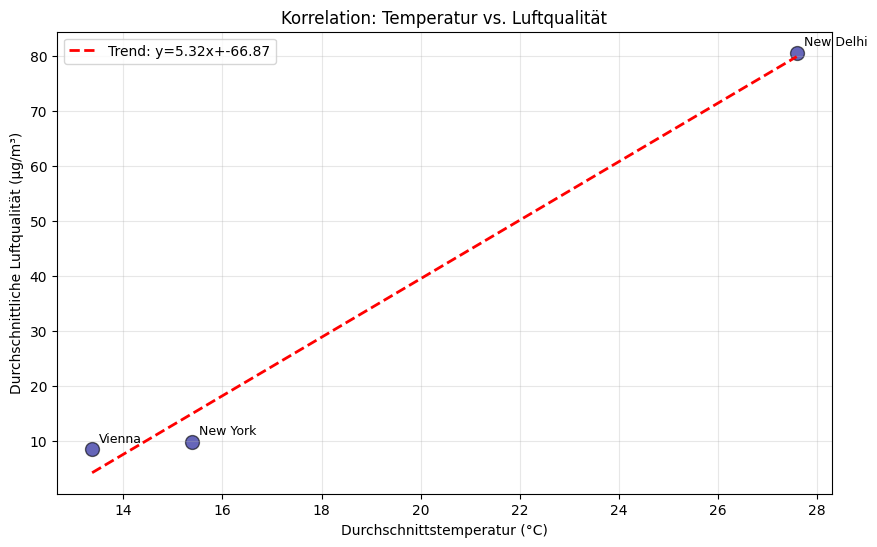

In [26]:
if summary_records:
    summary_df = pd.DataFrame(summary_records)
    summary_df = summary_df.dropna(subset=["average_temperature_c", "average_air_quality"])

    if not summary_df.empty and len(summary_df) > 1:
        fig, ax = plt.subplots(figsize=(10, 6))

        # Streudiagramm
        ax.scatter(summary_df["average_temperature_c"], summary_df["average_air_quality"],
                  s=100, color="darkblue", alpha=0.6, edgecolors="black")

        # Städte-Labels hinzufügen
        for idx, row in summary_df.iterrows():
            ax.annotate(row["city"],
                       (row["average_temperature_c"], row["average_air_quality"]),
                       xytext=(5, 5), textcoords="offset points", fontsize=9)

        # Trendlinie
        z = np.polyfit(summary_df["average_temperature_c"], summary_df["average_air_quality"], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(summary_df["average_temperature_c"].min(),
                             summary_df["average_temperature_c"].max(), 100)
        ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f"Trend: y={z[0]:.2f}x+{z[1]:.2f}")

        unit = summary_df.iloc[0]['air_quality_unit']
        ax.set_xlabel("Durchschnittstemperatur (°C)")
        ax.set_ylabel(f"Durchschnittliche Luftqualität ({unit})")
        ax.set_title("Korrelation: Temperatur vs. Luftqualität")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()
    else:
        print("Mindestens 2 Städte mit gültigen Daten erforderlich.")
else:
    print("MapReduce-Ergebnisse nicht verfügbar.")

Aus dem Streudiagramm ist ersichtlich, dass es einen positiven Zusammenhang zwischen der Durchschnittstemperatur und der Luftverschmutzung gibt. Das bedeutet, dass höhere Temperaturen tendenziell mit schlechterer Luftqualität einhergehen. Allerdings ist die Anzahl der Datenpunkte begrenzt, sodass diese Beobachtung mit Vorsicht interpretiert werden sollte. Weitere Datenpunkte und eine detailliertere Analyse wären notwendig, um eine fundierte Aussage über die Korrelation zwischen Temperatur und Luftqualität treffen zu können.

## Aufraeumen und herunterfahren

Wenn du am Ende wieder ein sauberes System haben willst, kannst du zuerst den MongoDB-Container samt Compose-Ressourcen stoppen. Das Beenden von Docker Desktop ist optional und betrifft alle laufenden Docker-Container.


### Umgebung aufräumen

Die folgende Zelle stoppt den MongoDB-Container und räumt die Docker-Compose-Ressourcen auf. Die Befehle liegen direkt in dieser Notebook-Zelle.


In [ ]:
import subprocess

subprocess.run(["docker", "compose", "down"], cwd=project_dir, check=True)
print("MongoDB-Container und Compose-Ressourcen wurden gestoppt.")

# Optional unter Linux mit Docker Desktop als User-Service:
# subprocess.run(["systemctl", "--user", "stop", "docker-desktop"], check=True)
# print("Docker Desktop wurde gestoppt.")
